# Object Detection
This notebook trains convolutional object detection models on a 2x3 grid setup, selects the best model on validation performance, and evaluates it on the test set.


## 1) Imports and runtime setup
This cell imports all required libraries, sets a random seed, and picks CPU or GPU automatically.


In [23]:
import itertools
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataset import TensorDataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchmetrics.detection.mean_ap import MeanAveragePrecision


torch.manual_seed(123)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")


Training on device: cuda


## 2) Configuration
This cell defines image size, output grid size, number of classes, and the model variants that will be compared.


In [24]:
H_IN, W_IN = 48, 60
H_OUT, W_OUT = 2, 3
NUM_CLASSES = 2
OUT_CHANNELS = NUM_CLASSES + 5

model_configs = {
    'small': {'channels': (16, 32), 'head_channels': 64, 'dropout': 0.10},
    'base': {'channels': (16, 32, 64), 'head_channels': 128, 'dropout': 0.10},
    'deep': {'channels': (16, 32, 64, 96), 'head_channels': 160, 'dropout': 0.15},
}



## 3) Detection model
This is a fully convolutional detector that outputs `(N, C+5, H_OUT, W_OUT)` where each cell predicts objectness, bounding box, and class logits.


In [25]:
class DetectionCNN(nn.Module):
    def __init__(self, channels=(16, 32, 64), head_channels=128, dropout=0.10, num_classes=NUM_CLASSES):
        super().__init__()

        blocks = []
        in_channels = 1
        for out_channels in channels:
            blocks.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ])
            in_channels = out_channels

        self.backbone = nn.Sequential(*blocks)
        self.grid_pool = nn.AdaptiveAvgPool2d((H_OUT, W_OUT))
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, head_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(head_channels, num_classes + 5, kernel_size=1),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.grid_pool(x)
        return self.head(x)



## 4) Loss and geometric helpers
This cell defines the detection loss (objectness + bounding box + class) and utility functions for IoU and coordinate conversion.


In [26]:
def _mean_or_zero(values, device):
    return values.mean() if values.numel() > 0 else torch.tensor(0.0, device=device)


def detection_loss(y_pred, y_true, lambda_noobj=0.25, lambda_bbox=2.0, lambda_cls=1.0):
    """
    y_pred: (N, C+5, H_OUT, W_OUT)
    y_true: (N, H_OUT, W_OUT, 6)
    """
    y_pred = y_pred.permute(0, 2, 3, 1)

    true_object = y_true[..., 0].float()
    pred_object_logits = y_pred[..., 0]

    bce = F.binary_cross_entropy_with_logits(pred_object_logits, true_object, reduction='none')
    object_mask = true_object > 0.5
    no_object_mask = ~object_mask

    object_loss = _mean_or_zero(bce[object_mask], y_pred.device)
    no_object_loss = _mean_or_zero(bce[no_object_mask], y_pred.device)
    detection_term = object_loss + lambda_noobj * no_object_loss

    pred_xy = torch.sigmoid(y_pred[..., 1:3])
    pred_wh = F.softplus(y_pred[..., 3:5])
    pred_bbox = torch.cat([pred_xy, pred_wh], dim=-1)
    true_bbox = y_true[..., 1:5].float()

    bbox_term = _mean_or_zero(
        F.smooth_l1_loss(pred_bbox[object_mask], true_bbox[object_mask], reduction='none').mean(dim=-1),
        y_pred.device,
    )

    class_logits = y_pred[..., 5:]
    class_targets = y_true[..., 5].long().clamp(min=0, max=NUM_CLASSES - 1)
    class_term = _mean_or_zero(
        F.cross_entropy(class_logits[object_mask], class_targets[object_mask], reduction='none'),
        y_pred.device,
    )

    return detection_term + lambda_bbox * bbox_term + lambda_cls * class_term


def xywh_iou(box1, box2):
    """
    box1, box2: (..., 4), format [x_center, y_center, width, height]
    """
    box1_min = box1[..., :2] - 0.5 * box1[..., 2:]
    box1_max = box1[..., :2] + 0.5 * box1[..., 2:]
    box2_min = box2[..., :2] - 0.5 * box2[..., 2:]
    box2_max = box2[..., :2] + 0.5 * box2[..., 2:]

    inter_min = torch.maximum(box1_min, box2_min)
    inter_max = torch.minimum(box1_max, box2_max)
    inter_wh = (inter_max - inter_min).clamp(min=0)
    inter_area = inter_wh[..., 0] * inter_wh[..., 1]

    area1 = (box1[..., 2] * box1[..., 3]).clamp(min=0)
    area2 = (box2[..., 2] * box2[..., 3]).clamp(min=0)
    union = area1 + area2 - inter_area

    return torch.where(union > 0, inter_area / union, torch.zeros_like(union))


def local_to_global(row, col, local_box):
    x, y, w, h = local_box
    cell_w = 1.0 / W_OUT
    cell_h = 1.0 / H_OUT
    global_x = (col + x) * cell_w
    global_y = (row + y) * cell_h
    global_w = w * cell_w
    global_h = h * cell_h
    return global_x, global_y, global_w, global_h


def xywh_to_xyxy(box):
    x, y, w, h = box
    x1 = x - 0.5 * w
    y1 = y - 0.5 * h
    x2 = x + 0.5 * w
    y2 = y + 0.5 * h
    return x1, y1, x2, y2



## 5) Load datasets
This follows the same style as `Object_localization.ipynb`: simple train/val/test loading from `../data_2`, then basic size checks. A safe loader is used for PyTorch 2.6+.


In [27]:
data_path = '../data_2/'


def safe_load(path):
    if hasattr(torch.serialization, 'safe_globals'):
        with torch.serialization.safe_globals([TensorDataset]):
            return torch.load(path, map_location='cpu')
    torch.serialization.add_safe_globals([TensorDataset])
    return torch.load(path, map_location='cpu')


train_data = safe_load(f"{data_path}detection_train.pt")
val_data = safe_load(f"{data_path}detection_val.pt")
test_data = safe_load(f"{data_path}detection_test.pt")

print(len(train_data))
print(len(val_data))
print(len(test_data))



26874
2967
4981


## 6) Normalization and DataLoaders
This cell computes normalization statistics from the training set and creates dataset wrappers and dataloaders.


In [28]:
def ensure_channel_first(image):
    image = image.float()
    if image.ndim == 2:
        image = image.unsqueeze(0)
    return image


train_images = torch.stack([ensure_channel_first(image) for image, _ in train_data], dim=0)
train_mean = train_images.mean()
train_std = train_images.std().clamp_min(1e-6)
print(f"Train mean: {train_mean.item():.4f}, train std: {train_std.item():.4f}")


def preprocessor(image):
    return (image - train_mean) / train_std


class DetectionDataset(Dataset):
    def __init__(self, data, preprocessor=None):
        self.data = data
        self.preprocessor = preprocessor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        image, target = self.data[index]
        image = ensure_channel_first(image)
        target = target.float()
        if self.preprocessor is not None:
            image = self.preprocessor(image)
        return image, target


batch_size = 128
train_loader = DataLoader(DetectionDataset(train_data, preprocessor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(DetectionDataset(val_data, preprocessor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(DetectionDataset(test_data, preprocessor), batch_size=batch_size, shuffle=False)



Train mean: 0.2989, train std: 0.1967


In [ ]:
# Helper used during tuning and final evaluation. 
def get_map_results(model, eval_loader, device):
    model.eval()
    predictions_list = []
    targets_list = []

    with torch.no_grad():
        for images, targets in eval_loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images).permute(0, 2, 3, 1)

            batch_size = images.shape[0]
            for batch_index in range(batch_size):
                output_grid = outputs[batch_index]
                target_grid = targets[batch_index]

                pred_boxes = []
                pred_scores = []
                pred_labels = []
                true_boxes = []
                true_labels = []

                for row in range(H_OUT):
                    for col in range(W_OUT):
                        pred_cell = output_grid[row, col]
                        target_cell = target_grid[row, col]

                        pred_object = torch.sigmoid(pred_cell[0])
                        if pred_object > 0.5:
                            px = torch.sigmoid(pred_cell[1])
                            py = torch.sigmoid(pred_cell[2])
                            pw = F.softplus(pred_cell[3])
                            ph = F.softplus(pred_cell[4])

                            class_probs = F.softmax(pred_cell[5:], dim=0)
                            pred_label = torch.argmax(class_probs)
                            score = pred_object * class_probs[pred_label]

                            global_box = local_to_global(
                                row, col, torch.stack([px, py, pw, ph])
                            )
                            pred_xyxy = torch.stack(xywh_to_xyxy(global_box))

                            pred_boxes.append(pred_xyxy)
                            pred_scores.append(score)
                            pred_labels.append(pred_label)

                        if target_cell[0] > 0.5:
                            global_box = local_to_global(row, col, target_cell[1:5])
                            true_xyxy = torch.stack(xywh_to_xyxy(global_box))
                            true_boxes.append(true_xyxy)
                            true_labels.append(target_cell[5].long())

                if len(pred_boxes) == 0:
                    pred_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                else:
                    pred_dict = {
                        "boxes": torch.stack(pred_boxes),
                        "scores": torch.stack(pred_scores).float(),
                        "labels": torch.stack(pred_labels).long(),
                    }
                predictions_list.append(pred_dict)

                if len(true_boxes) == 0:
                    target_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                else:
                    target_dict = {
                        "boxes": torch.stack(true_boxes),
                        "labels": torch.stack(true_labels).long(),
                    }
                targets_list.append(target_dict)

    metric = MeanAveragePrecision(iou_type="bbox")
    metric.update(predictions_list, targets_list)
    return metric.compute()

## 7) Training helper
This function trains one model variant, keeps the best checkpoint by validation loss, and logs epoch time.


In [ ]:
def train_single_model(model, train_loader, val_loader, num_epochs=30, learning_rate=1e-3, weight_decay=1e-4):
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        'train_loss': [],
        'val_loss': [],
        'epoch_time_sec': [],
    }

    best_val_loss = float('inf')
    best_state = None
    training_start = time.perf_counter()

    for epoch in range(num_epochs):
        epoch_start = time.perf_counter()

        model.train()
        train_loss_sum = 0.0
        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            predictions = model(images)
            loss = detection_loss(predictions, targets)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * images.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                targets = targets.to(device)
                predictions = model(images)
                loss = detection_loss(predictions, targets)
                val_loss_sum += loss.item() * images.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

        epoch_time = time.perf_counter() - epoch_start
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_time_sec'].append(epoch_time)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
            f"time: {epoch_time:.2f}s"
        )

    history['total_time_sec'] = time.perf_counter() - training_start

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Total training time: {history['total_time_sec']:.2f}s")
    return model, history




## 8) Hyperparameter tuning

This cell runs a simple grid search with `itertools`, trains one model per configuration, evaluates each model with `get_map_results()`, and keeps the best run by validation mAP@0.5.


In [ ]:
hyperparameter_space = {
    'model_name': ['small', 'base', 'deep'],
    'learning_rate': [1e-3, 5e-4],
    'weight_decay': [1e-4, 1e-5],
    'num_epochs': [15],
}

keys = list(hyperparameter_space.keys())
all_combinations = list(itertools.product(*(hyperparameter_space[key] for key in keys)))

trained_models = {}
training_histories = {}

best_map50 = float('-inf')
best_hyperparameters = None
best_model_name = None
best_model = None

print(f"Total combinations: {len(all_combinations)}")

for run_index, values in enumerate(all_combinations, start=1):
    current_hparams = dict(zip(keys, values))
    run_name = f"run_{run_index:02d}"

    print(f"\n[{run_index}/{len(all_combinations)}] {run_name}: {current_hparams}")

    model_config = model_configs[current_hparams['model_name']]
    current_model = DetectionCNN(**model_config).to(device)

    current_model, history = train_single_model(
        current_model,
        train_loader,
        val_loader,
        num_epochs=current_hparams['num_epochs'],
        learning_rate=current_hparams['learning_rate'],
        weight_decay=current_hparams['weight_decay'],
    )

    map_results = get_map_results(current_model, val_loader, device)
    val_map50 = float(map_results['map_50'].item())

    trained_models[run_name] = current_model
    training_histories[run_name] = history

    print(f"{run_name} validation mAP@0.5: {val_map50:.4f}")

    if val_map50 > best_map50:
        best_map50 = val_map50
        best_hyperparameters = current_hparams.copy()
        best_model_name = run_name
        best_model = current_model

if best_model is None:
    raise RuntimeError('No model was trained during hyperparameter tuning.')

model = best_model

print("\nBest hyperparameters (by validation mAP@0.5):")
print(best_hyperparameters)
print(f"Best run: {best_model_name}")
print(f"Best validation mAP@0.5: {best_map50:.4f}")



Training model: small
Epoch 01/30 | train loss: 0.6560 | val loss: 0.3768 | time: 2.54s
Epoch 02/30 | train loss: 0.3594 | val loss: 0.3405 | time: 2.68s
Epoch 03/30 | train loss: 0.2918 | val loss: 0.2582 | time: 2.60s
Epoch 04/30 | train loss: 0.2551 | val loss: 0.2321 | time: 2.75s
Epoch 05/30 | train loss: 0.2241 | val loss: 0.2021 | time: 2.60s
Epoch 06/30 | train loss: 0.2024 | val loss: 0.1887 | time: 2.63s
Epoch 07/30 | train loss: 0.1884 | val loss: 0.2588 | time: 2.69s
Epoch 08/30 | train loss: 0.1743 | val loss: 0.1580 | time: 2.61s
Epoch 09/30 | train loss: 0.1613 | val loss: 0.1770 | time: 2.79s
Epoch 10/30 | train loss: 0.1541 | val loss: 0.1510 | time: 2.58s
Epoch 11/30 | train loss: 0.1481 | val loss: 0.1737 | time: 2.77s
Epoch 12/30 | train loss: 0.1400 | val loss: 0.1482 | time: 2.79s
Epoch 13/30 | train loss: 0.1361 | val loss: 0.1670 | time: 2.78s
Epoch 14/30 | train loss: 0.1370 | val loss: 0.1245 | time: 2.71s
Epoch 15/30 | train loss: 0.1276 | val loss: 0.1269 |

## 9) Evaluation metrics
This cell computes detection accuracy and IoU on cells that contain objects in ground truth.


In [31]:
def compute_detection_accuracy(model, loader):
    model.eval()
    total_object_cells = 0
    correct_predictions = 0

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            predictions = model(images).permute(0, 2, 3, 1)

            true_object = targets[..., 0] > 0.5
            pred_object = torch.sigmoid(predictions[..., 0]) > 0.5
            pred_class = predictions[..., 5:].argmax(dim=-1)
            true_class = targets[..., 5].long()

            total_object_cells += true_object.sum().item()
            correct_predictions += (true_object & pred_object & (pred_class == true_class)).sum().item()

    return correct_predictions / total_object_cells if total_object_cells > 0 else 0.0


def compute_detection_iou(model, loader):
    model.eval()
    total_iou = 0.0
    total_object_cells = 0

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            predictions = model(images).permute(0, 2, 3, 1)

            true_object = targets[..., 0] > 0.5
            if not true_object.any():
                continue

            pred_object = torch.sigmoid(predictions[..., 0]) > 0.5
            pred_xy = torch.sigmoid(predictions[..., 1:3])
            pred_wh = F.softplus(predictions[..., 3:5])
            pred_bbox = torch.cat([pred_xy, pred_wh], dim=-1)
            true_bbox = targets[..., 1:5]

            iou_values = xywh_iou(pred_bbox, true_bbox)
            iou_values = iou_values * pred_object.float()

            total_iou += iou_values[true_object].sum().item()
            total_object_cells += true_object.sum().item()

    return total_iou / total_object_cells if total_object_cells > 0 else 0.0



## 10) Evaluate best tuned model on test set

This cell evaluates the best model selected during hyperparameter tuning.


In [32]:
if 'best_model' not in globals() or best_model is None:
    raise RuntimeError('No tuned best model found. Run the hyperparameter tuning cell first.')

print(f"Best run from tuning: {best_model_name}")
print(f"Best hyperparameters: {best_hyperparameters}")
print(f"Best validation mAP@0.5: {best_map50:.4f}")

test_accuracy = compute_detection_accuracy(best_model, test_loader)
test_iou = compute_detection_iou(best_model, test_loader)
test_overall = 0.5 * (test_accuracy + test_iou)
test_map_results = get_map_results(best_model, test_loader, device)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test IoU:      {test_iou:.4f}")
print(f"Test overall:  {test_overall:.4f}")
print(f"Test mAP@0.5:  {float(test_map_results['map_50'].item()):.4f}")
print(f"Test mAP:      {float(test_map_results['map'].item()):.4f}")


Validation results:
   small | mAP@0.5: 0.6335 | mAP: 0.2207 | accuracy: 0.9853 | IoU: 0.5928 | overall: 0.7890
    base | mAP@0.5: 0.8811 | mAP: 0.4180 | accuracy: 0.9888 | IoU: 0.7116 | overall: 0.8502
    deep | mAP@0.5: 0.8948 | mAP: 0.4039 | accuracy: 0.9885 | IoU: 0.7065 | overall: 0.8475

Selected best model (by val mAP@0.5): deep
Test accuracy: 0.9898
Test IoU:      0.7067
Test overall:  0.8482
Test mAP@0.5:  0.8957
Test mAP:      0.4038


## 11) Prediction decoding and visualization helpers
These helpers convert model outputs to global boxes and draw both true and predicted boxes on images.


In [33]:
def decode_true_boxes(target_grid):
    boxes = []
    for row in range(H_OUT):
        for col in range(W_OUT):
            cell = target_grid[row, col]
            if cell[0] > 0.5:
                global_box = local_to_global(row, col, cell[1:5])
                label = int(cell[5].item())
                boxes.append((global_box, label))
    return boxes


def decode_pred_boxes(pred_grid, object_threshold=0.5):
    pred_grid = pred_grid.permute(1, 2, 0)
    boxes = []

    for row in range(H_OUT):
        for col in range(W_OUT):
            cell = pred_grid[row, col]
            object_score = torch.sigmoid(cell[0]).item()
            if object_score > object_threshold:
                px = torch.sigmoid(cell[1]).item()
                py = torch.sigmoid(cell[2]).item()
                pw = F.softplus(cell[3]).item()
                ph = F.softplus(cell[4]).item()
                class_probabilities = F.softmax(cell[5:], dim=0)
                label = int(torch.argmax(class_probabilities).item())
                score = object_score * class_probabilities[label].item()
                global_box = local_to_global(row, col, torch.tensor([px, py, pw, ph]))
                boxes.append((global_box, label, score))

    return boxes


def draw_box(ax, box_xywh, color, text=None):
    x, y, w, h = box_xywh
    x1 = (x - 0.5 * w) * W_IN
    y1 = (y - 0.5 * h) * H_IN
    width = w * W_IN
    height = h * H_IN

    rectangle = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rectangle)

    if text is not None:
        ax.text(x1, max(0, y1 - 2), text, color=color, fontsize=8, backgroundcolor='black')



## 12) Plot prediction examples
This cell plots samples from train, validation, and test data with true (green) and predicted (red) bounding boxes and labels.


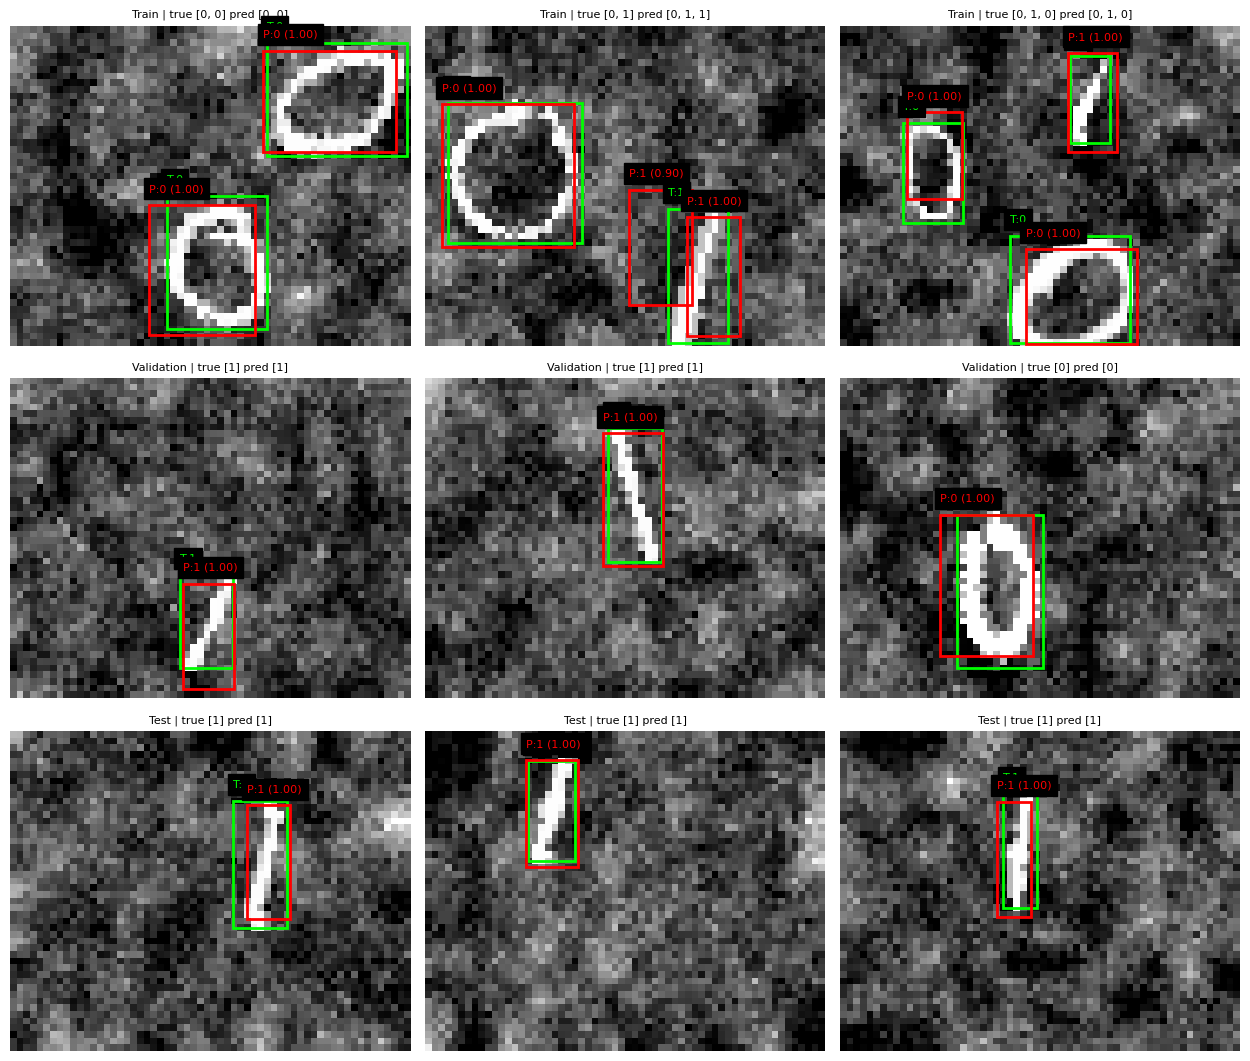

In [34]:
plot_model = globals().get('best_model', globals().get('model', None))
if plot_model is None:
    raise RuntimeError('No trained model found. Run training and model selection first.')

plot_model.eval()

splits = [
    ('Train', train_data),
    ('Validation', val_data),
    ('Test', test_data),
]

samples_per_split = 3
figure, axes = plt.subplots(len(splits), samples_per_split, figsize=(4.2 * samples_per_split, 3.6 * len(splits)))

with torch.no_grad():
    for row, (split_name, dataset) in enumerate(splits):
        indices = torch.randperm(len(dataset))[:samples_per_split]

        for col, index in enumerate(indices):
            ax = axes[row, col] if len(splits) > 1 else axes[col]
            image, target = dataset[int(index)]
            image = ensure_channel_first(image)

            model_input = preprocessor(image).unsqueeze(0).to(device)
            prediction = plot_model(model_input).cpu().squeeze(0)

            true_boxes = decode_true_boxes(target)
            pred_boxes = decode_pred_boxes(prediction, object_threshold=0.5)

            ax.imshow(image.squeeze(0), cmap='gray')

            true_labels = []
            pred_labels = []

            for box, label in true_boxes:
                true_labels.append(str(label))
                draw_box(ax, box, color='lime', text=f"T:{label}")

            for box, label, score in pred_boxes:
                pred_labels.append(str(label))
                draw_box(ax, box, color='red', text=f"P:{label} ({score:.2f})")

            ax.set_title(
                f"{split_name} | true [{', '.join(true_labels) if true_labels else '-'}] "
                f"pred [{', '.join(pred_labels) if pred_labels else '-'}]",
                fontsize=8,
            )
            ax.axis('off')

plt.tight_layout()
plt.show()

